<a href="https://colab.research.google.com/github/andreaprifti19/SINDy-Teaching-Usecases/blob/main/notebooks/01_damped_oscillator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
!pip install pysindy

In [104]:
import warnings

import numpy as np
import scipy
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.linalg import LinAlgWarning
from sklearn.metrics import mean_absolute_error
from sklearn.exceptions import ConvergenceWarning
import pysindy as ps

# STLSQ routinely raises these two in the robustness sweeps.They are
# suppressed so the sweep tables stay readable; any other warning still
# reaches us.

warnings.filterwarnings("ignore", category=LinAlgWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Fixed seed -> identical noise, identical numbers, on every run and every
# machine.
SEED = 0
rng = np.random.default_rng(SEED)

print("pysindy      ", ps.__version__)
print("numpy        ", np.__version__)
print("scipy        ", scipy.__version__)
print("scikit-learn ", sklearn.__version__)
print("matplotlib   ", matplotlib.__version__)

pysindy       2.1.0
numpy         2.1.3
scipy         1.16.3
scikit-learn  1.6.1
matplotlib    3.10.0


In [105]:
m = 1.0   # mass
k = 2.0   # spring constant
c = 0.3   # damping coefficient

def damped_oscillator(t, state):
    x, v = state
    return [v, -(k / m) * x - (c / m) * v]

# The answer we want SINDy to recover, written as a coefficient matrix.
# Rows = equations (x', v'); columns = library terms [1, x, v, x^2, x*v, v^2].
TRUE_COEF = np.array([
    [0.0,  0.0,   1.0,   0.0, 0.0, 0.0],   # x' = v
    [0.0, -k/m,  -c/m,   0.0, 0.0, 0.0],   # v' = -(k/m) x - (c/m) v
])

In [106]:
dt = 0.01                        # sampling interval
t = np.arange(0, 25, dt)         # 25 s ≈ 5.6 oscillation periods
x0 = [2.0, 0.0]                  # released from x = 2 at rest

sol = solve_ivp(damped_oscillator, (t[0], t[-1]), x0, t_eval=t, rtol=1e-10, atol=1e-12)
X = sol.y.T                      # shape (n_samples, 2): column 0 = x, column 1 = v

print("Data matrix shape:", X.shape)

Data matrix shape: (2500, 2)


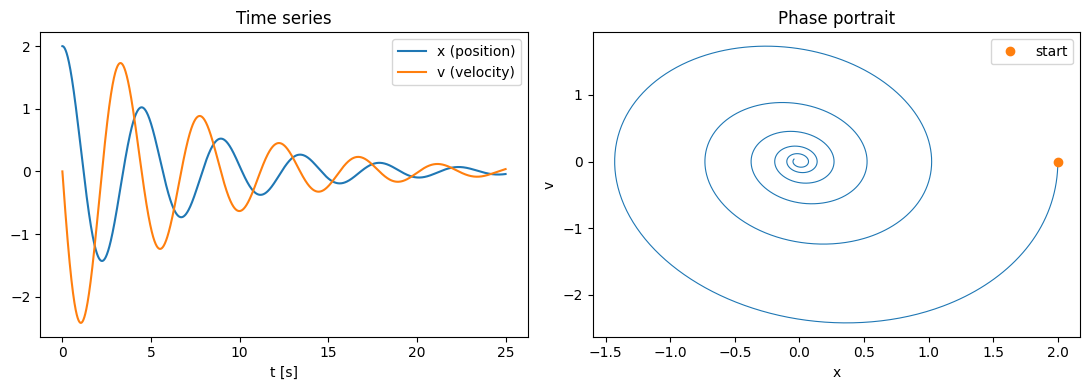

In [107]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, X[:, 0], label="x (position)")
ax[0].plot(t, X[:, 1], label="v (velocity)")
ax[0].set_xlabel("t [s]"); ax[0].legend(); ax[0].set_title("Time series")
ax[1].plot(X[:, 0], X[:, 1], lw=0.8)
ax[1].plot(X[0, 0], X[0, 1], "o", label="start")
ax[1].set_xlabel("x"); ax[1].set_ylabel("v"); ax[1].legend(); ax[1].set_title("Phase portrait")
plt.tight_layout(); plt.show()

In [108]:
model = ps.SINDy(
    differentiation_method=ps.FiniteDifference(order=2),
    feature_library=ps.PolynomialLibrary(degree=2),
    optimizer=ps.STLSQ(threshold=0.05),
)
model.fit(X, t=dt, feature_names=["x", "v"])

print("Candidate library:", model.get_feature_names())
print("\nDiscovered equations:")
model.print()

Candidate library: ['1', 'x', 'v', 'x^2', 'x v', 'v^2']

Discovered equations:
(x)' =  1.000 v
(v)' = -2.000 x + -0.300 v


In [109]:
def check_recovery(model, true_coef):
    '''Return (correct sparsity pattern?, max abs coefficient error).'''
    found = model.optimizer.coef_
    same_structure = np.array_equal(true_coef != 0, found != 0)
    return same_structure, np.abs(found - true_coef).max()

ok, max_err = check_recovery(model, TRUE_COEF)
print(f"Correct sparsity pattern : {ok}")
print(f"Max coefficient error    : {max_err:.2e}")
print(f"Mean abs coefficient err : {mean_absolute_error(TRUE_COEF, model.optimizer.coef_):.2e}")
print(f"R^2 on derivatives       : {model.score(X, t=dt):.6f}")

Correct sparsity pattern : True
Max coefficient error    : 6.25e-05
Mean abs coefficient err : 9.60e-06
R^2 on derivatives       : 1.000000


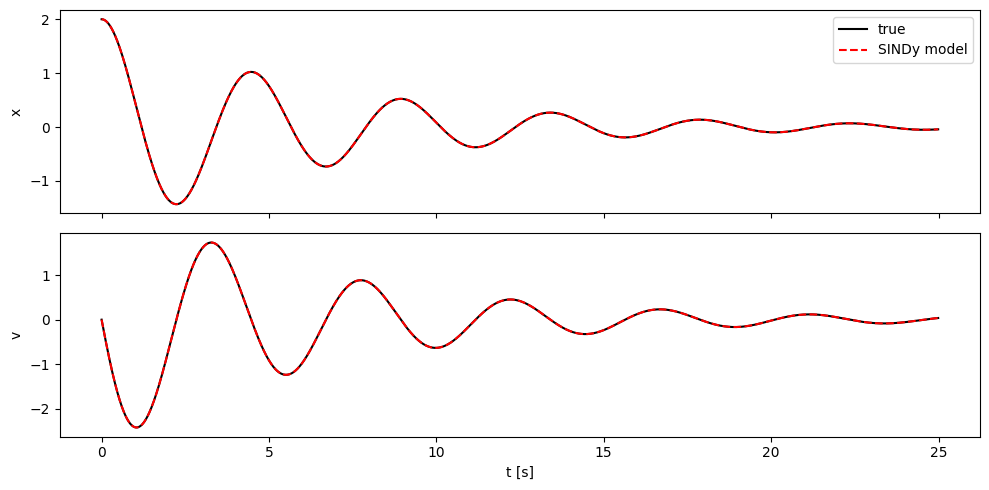

Max trajectory deviation: 0.0003205645659901668


In [110]:
# Forward simulation from the same initial condition, using only the discovered equations
X_sim = model.simulate(x0, t)

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for i, name in enumerate(["x", "v"]):
    ax[i].plot(t, X[:, i], "k", label="true")
    ax[i].plot(t, X_sim[:, i], "r--", label="SINDy model")
    ax[i].set_ylabel(name)
ax[0].legend(); ax[1].set_xlabel("t [s]")
plt.tight_layout(); plt.show()

print("Max trajectory deviation:", np.abs(X_sim - X).max())

In [111]:
def fit_sindy(X_data, diff_method=None, library=None, threshold=0.05):
    '''Fit SINDy with the notebook's default settings unless overridden.'''
    mdl = ps.SINDy(
        differentiation_method=diff_method or ps.FiniteDifference(order=2),
        feature_library=library or ps.PolynomialLibrary(degree=2),
        optimizer=ps.STLSQ(threshold=threshold),
    )
    mdl.fit(X_data, t=dt, feature_names=["x", "v"])
    return mdl


In [112]:
noise_levels = [0.0, 0.01, 0.05, 0.10, 0.20, 0.30, 0.50]
N_TRIALS = 10        # independent noise draws per level → success rate instead of a lucky/unlucky single run
smoothed = ps.SmoothedFiniteDifference(smoother_kws={"window_length": 51, "polyorder": 3})

results = []
for nl in noise_levels:
    ok_fd, err_fd, ok_sfd, err_sfd = [], [], [], []
    for _ in range(N_TRIALS):
        X_noisy = X + rng.normal(0, nl * X.std(axis=0), X.shape)
        a, b = check_recovery(fit_sindy(X_noisy), TRUE_COEF)
        c_, d = check_recovery(fit_sindy(X_noisy, diff_method=smoothed), TRUE_COEF)
        ok_fd.append(a); err_fd.append(b); ok_sfd.append(c_); err_sfd.append(d)
    results.append((nl, np.mean(ok_fd), np.median(err_fd), np.mean(ok_sfd), np.median(err_sfd)))

print(f"{'noise':>6} | {'FiniteDifference':>24} | {'SmoothedFiniteDiff':>24}")
print(f"{'':>6} | {'success rate':>13} {'median err':>10} | {'success rate':>13} {'median err':>10}")
for nl, sr_fd, e_fd, sr_sfd, e_sfd in results:
    print(f"{nl*100:5.0f}% | {sr_fd*100:12.0f}% {e_fd:10.3f} | {sr_sfd*100:12.0f}% {e_sfd:10.3f}")

 noise |         FiniteDifference |       SmoothedFiniteDiff
       |  success rate median err |  success rate median err
    0% |          100%      0.000 |          100%      0.000
    1% |          100%      0.005 |          100%      0.001
    5% |           90%      0.018 |          100%      0.004
   10% |           60%      0.058 |          100%      0.010
   20% |            0%      0.163 |          100%      0.020
   30% |            0%      0.291 |           60%      0.044
   50% |            0%      0.711 |           10%      0.099


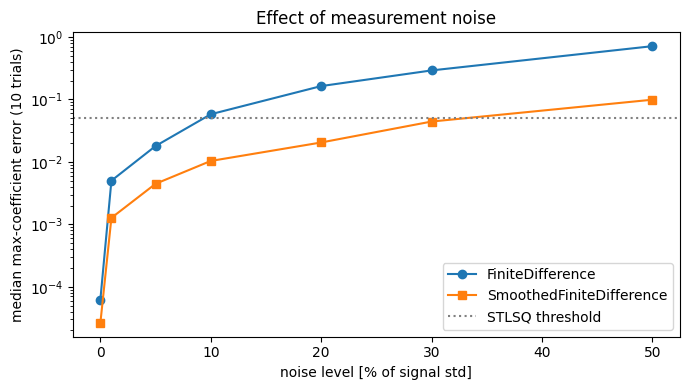

In [113]:
fig, ax = plt.subplots(figsize=(7, 4))
nl  = [r[0]*100 for r in results]
ax.plot(nl, [r[2] for r in results], "o-", label="FiniteDifference")
ax.plot(nl, [r[4] for r in results], "s-", label="SmoothedFiniteDifference")
ax.axhline(0.05, color="gray", ls=":", label="STLSQ threshold")
ax.set_xlabel("noise level [% of signal std]"); ax.set_ylabel(f"median max-coefficient error ({N_TRIALS} trials)")
ax.set_yscale("log"); ax.legend(); ax.set_title("Effect of measurement noise")
plt.tight_layout(); plt.show()

In [114]:
# Look at an actual failure: what does SINDy return at 20% noise?
X_noisy = X + rng.normal(0, 0.20 * X.std(axis=0), X.shape)
print("--- 20% noise, FiniteDifference ---")
fit_sindy(X_noisy).print()
print("\n--- 20% noise, SmoothedFiniteDifference ---")
fit_sindy(X_noisy, diff_method=smoothed).print()

--- 20% noise, FiniteDifference ---
(x)' = -0.054 x +  0.959 v + -0.115 x^2
(v)' =  0.055 1 + -1.963 x + -0.289 v + -0.096 x^2 + -0.053 x v

--- 20% noise, SmoothedFiniteDifference ---
(x)' =  1.006 v
(v)' = -1.951 x + -0.301 v


In [115]:
fractions = [1.0, 0.5, 0.25, 0.15, 0.10, 0.05]
period = 2 * np.pi / np.sqrt(k / m)

print(f"{'fraction':>8} {'samples':>8} {'duration':>9} {'periods':>8} | {'success rate':>13} {'median err':>10}")
for fr in fractions:
    n = int(len(t) * fr)
    oks, errs = [], []
    for _ in range(N_TRIALS):
        X_noisy = X + rng.normal(0, 0.05 * X.std(axis=0), X.shape)
        ok, err = check_recovery(fit_sindy(X_noisy[:n]), TRUE_COEF)
        oks.append(ok); errs.append(err)
    print(f"{fr*100:7.0f}% {n:8d} {n*dt:8.2f}s {n*dt/period:8.2f} | {np.mean(oks)*100:12.0f}% {np.median(errs):10.3f}")

fraction  samples  duration  periods |  success rate median err
    100%     2500    25.00s     5.63 |          100%      0.022
     50%     1250    12.50s     2.81 |           80%      0.020
     25%      625     6.25s     1.41 |           80%      0.019
     15%      375     3.75s     0.84 |           10%      1.309
     10%      250     2.50s     0.56 |            0%      3.536
      5%      125     1.25s     0.28 |            0%     15.693


In [116]:
for deg in [1, 2, 5]:
    mdl = fit_sindy(X, library=ps.PolynomialLibrary(degree=deg))
    n_terms = mdl.optimizer.coef_.shape[1]
    n_used  = (mdl.optimizer.coef_ != 0).sum()
    print(f"--- polynomial degree {deg}: {n_terms} candidates, {n_used} kept ---")
    mdl.print(); print()

print("--- Fourier library (sin/cos only) ---")
mdl_fourier = fit_sindy(X, library=ps.FourierLibrary(n_frequencies=2))
mdl_fourier.print()
print(f"\n{(mdl_fourier.optimizer.coef_ != 0).sum()} nonzero terms — no sparse solution exists in this basis")

print("\n--- Combined Polynomial + Fourier library ---")
combined = ps.PolynomialLibrary(degree=2) + ps.FourierLibrary(n_frequencies=1)
mdl_combined = fit_sindy(X, library=combined)
mdl_combined.print()
print(f"\n{(mdl_combined.optimizer.coef_ != 0).sum()} nonzero terms kept")

--- polynomial degree 1: 3 candidates, 3 kept ---
(x)' =  1.000 v
(v)' = -2.000 x + -0.300 v

--- polynomial degree 2: 6 candidates, 3 kept ---
(x)' =  1.000 v
(v)' = -2.000 x + -0.300 v

--- polynomial degree 5: 21 candidates, 3 kept ---
(x)' =  1.000 v
(v)' = -2.000 x + -0.300 v

--- Fourier library (sin/cos only) ---
(x)' = -0.430 cos(1 x) +  1.670 sin(1 v) +  0.448 cos(1 v) +  0.177 cos(2 x) + -0.386 sin(2 v) + -0.203 cos(2 v)
(v)' = -3.216 sin(1 x) +  0.133 cos(1 x) + -0.500 sin(1 v) + -0.201 cos(1 v) +  0.694 sin(2 x) +  0.123 sin(2 v) +  0.077 cos(2 v)

13 nonzero terms — no sparse solution exists in this basis

--- Combined Polynomial + Fourier library ---
(x)' =  1.000 v
(v)' = -2.000 x + -0.300 v

3 nonzero terms kept
